In [1]:
import pandas as pd

In [ ]:
pd.set_option("display.max_columns", None)

In [3]:
psm = pd.read_csv('../data/open_psm.tsv', sep='\t')
psm.head(3)

,Spectrum,Spectrum File,Peptide,Modified Peptide,Extended Peptide,Prev AA,Next AA,Peptide Length,Charge,Retention,Observed Mass,Calibrated Observed Mass,Observed M/Z,Calibrated Observed M/Z,Calculated Peptide Mass,Calculated M/Z,Delta Mass,Expectation,Hyperscore,Nextscore,Probability,Qvalue,Number of Enzymatic Termini,Number of Missed Cleavages,Protein Start,Protein End,Intensity,Assigned Modifications,Observed Modifications,Purity,Is Decoy,Is Contaminant,Is Unique,Protein,Protein ID,Entry Name,Gene,Protein Description,Mapped Genes,Mapped Proteins,Parent Scan Number,Apex Retention Time,Apex Scan Number,Retention Time Start,Retention Time End,Retention Time FWHM,Traced Scans
0,GR_LCL_2D_ETHCD_fr1_immunopeptidome.00955.00955.2,interact-GR_LCL_2D_ETHCD_fr1_immunopeptidome.p...,SPAQDQDHP,NaN,TPPRVTGT.SPAQDQDHP.SEEQGGQG,T,S,9,2,2296.5430,993.4280,993.4280,497.7213,497.7213,993.4152,497.7149,0.0128,1.489000,23.976,22.817,1.0000,0.000000,0,0,1112,1120,0.00,NaN,NaN,0.0,False,False,False,sp|Q587J7|TDR12_HUMAN,Q587J7,TDR12_HUMAN,TDRD12,Putative ATP-dependent RNA helicase TDRD12,NaN,"tr|A0A1B0GU57|A0A1B0GU57_HUMAN, tr|A0A1W2PRK2|...",954,0.000,0,0.0000,0.000,0.00,0
1,GR_LCL_2D_ETHCD_fr1_immunopeptidome.01021.01021.2,interact-GR_LCL_2D_ETHCD_fr1_immunopeptidome.p...,PASAVETEY,NaN,HVNPEYFP.PASAVETEY.NIMKFHSF,P,N,9,2,2460.6804,1002.4060,1002.4060,502.2103,502.2103,965.4341,483.7243,36.9718,2.864000,16.389,14.287,0.7787,0.003816,0,0,972,980,0.00,NaN,NaN,0.0,False,False,False,sp|O15050|TRNK1_HUMAN,O15050,TRNK1_HUMAN,TRANK1,TPR and ankyrin repeat-containing protein 1,NaN,"tr|A0A2R8Y7N6|A0A2R8Y7N6_HUMAN, tr|A0A2R8Y8A3|...",1020,0.000,0,0.0000,0.000,0.00,0
2,GR_LCL_2D_ETHCD_fr1_immunopeptidome.01032.01032.2,interact-GR_LCL_2D_ETHCD_fr1_immunopeptidome.p...,APAPVQPPM,APAPVQPPM[147],PPVPASHI.APAPVQPPM.IRRDITFP,I,I,9,2,2486.9940,922.4579,922.4579,462.2362,462.2362,922.4582,462.2364,-0.0003,0.003164,31.237,31.237,1.0000,0.000000,0,0,1626,1634,140532.75,9M(15.9949),NaN,0.0,False,False,False,sp|O14497|ARI1A_HUMAN,O14497,ARI1A_HUMAN,ARID1A,AT-rich interactive domain-containing protein 1A,NaN,sp|LIEPE-NOT-SPLICED-12;|O14497|ARI1A;1626_163...,1031,2514.207,1042,2432.6992,2592.311,104.48,4


In [10]:
columns = [
    'Spectrum',	
    'Peptide', 
    'Peptide Length',
    'Protein ID', 
    'Protein',
    'Gene', 
    'Mapped Proteins', 
    'Hyperscore', 
    'Nextscore', 
    'Qvalue', 
    'Probability', 
    'Delta Mass', 
    'Retention',
    'Intensity',  
    'Is Decoy', 
    'Is Contaminant']

psm = psm[columns]

psm["DeltaScore"] = (
    psm["Hyperscore"]
    - psm["Nextscore"]
)


psm.head(2)

,Spectrum,Peptide,Peptide Length,Protein ID,Protein,Gene,Mapped Proteins,Hyperscore,Nextscore,Qvalue,Probability,Delta Mass,Retention,Intensity,Is Decoy,Is Contaminant,DeltaScore
0,GR_LCL_2D_ETHCD_fr1_immunopeptidome.00955.00955.2,SPAQDQDHP,9,Q587J7,sp|Q587J7|TDR12_HUMAN,TDRD12,"tr|A0A1B0GU57|A0A1B0GU57_HUMAN, tr|A0A1W2PRK2|...",23.976,22.817,0.000000,1.0000,0.0128,2296.5430,0.0,False,False,1.159
1,GR_LCL_2D_ETHCD_fr1_immunopeptidome.01021.01021.2,PASAVETEY,9,O15050,sp|O15050|TRNK1_HUMAN,TRANK1,"tr|A0A2R8Y7N6|A0A2R8Y7N6_HUMAN, tr|A0A2R8Y8A3|...",16.389,14.287,0.003816,0.7787,36.9718,2460.6804,0.0,False,False,2.102


In [11]:
len(psm['Spectrum'].unique())

16584

In [12]:
len(psm['Peptide'].unique())

10721

In [13]:
psm_filtered = psm.loc[psm.groupby('Peptide')['DeltaScore'].idxmax()]
psm_filtered.shape

(10721, 17)

In [14]:
def classify_row_with_first_hit_priority(row):

    protein = str(row["Protein"]) if pd.notna(row["Protein"]) else ""
    mapped = str(row["Mapped Proteins"]) if pd.notna(row["Mapped Proteins"]) else ""

    # join all hits
    is_spliced = "LIEPE-SPLICED" in protein
    is_not_spliced = "LIEPE-NOT-SPLICED" in protein
    is_swissprot = "sp|" in protein and not (
        protein.startswith("sp|LIEPE")
    )
    is_trembl = "tr|" in protein

    mapped_empty = pd.isna(mapped) or str(mapped).strip() == ""
    mapped_spliced = "LIEPE-SPLICED" in mapped
    mapped_not_spliced = "LIEPE-NOT-SPLICED" in mapped
    mapped_swissprot = "sp|" in mapped and not (
        mapped.startswith("sp|LIEPE")
    )
    mapped_trembl = "tr|" in mapped


    # classification
    if is_not_spliced:
        return "Liepe_not_spliced"
    elif is_swissprot:
        return "Swiss-Prot"
    elif is_trembl:
        return "TrEMBL"
    elif is_spliced:
        if mapped_empty:
            return "Spliced_only"
        elif mapped_spliced and not mapped_swissprot and not mapped_trembl:
            return "Spliced_with_LIEPE-SPLICED_alternative"
        elif mapped_not_spliced and not mapped_swissprot and not mapped_trembl:
            return "Spliced_with_LIEPE-NOT-SPLICED_alternative"
        elif mapped_swissprot and not mapped_spliced and not mapped_not_spliced and not mapped_trembl:
            return "Spliced_with_Swiss-Prot_alternative"
        elif mapped_trembl and not mapped_spliced and not mapped_not_spliced and not mapped_swissprot:
            return "Spliced_with_TrEMBL_alternative"
        elif mapped_swissprot and mapped_trembl and not mapped_spliced and not mapped_not_spliced:
            return "Spliced_with_Uniprot_alternative"
        else:
            return "Spliced_with_alternative"
    else:
        return "Other"
    

In [15]:
psm_filtered["Class"] = psm_filtered.apply(classify_row_with_first_hit_priority, axis=1)
psm_filtered.head(15)

,Spectrum,Peptide,Peptide Length,Protein ID,Protein,Gene,Mapped Proteins,Hyperscore,Nextscore,Qvalue,Probability,Delta Mass,Retention,Intensity,Is Decoy,Is Contaminant,DeltaScore,Class
2196,GR_LCL_2D_ETHCD_fr3_immunopeptidome.01747.01747.2,AAACQNGSIQI,11,Q9NW82,sp|Q9NW82|WDR70_HUMAN,WDR70,tr|D6RIW8|D6RIW8_HUMAN,24.730,23.809,0.000651,0.9989,-114.0814,3130.6287,0.00,False,False,0.921,Swiss-Prot
1766,GR_LCL_2D_ETHCD_fr2_immunopeptidome.04745.04745.2,AAAEPKLFGGF,11,P12931,sp|P12931|SRC_HUMAN,SRC,"sp|LIEPE-NOT-SPLICED-5388;|P12931|SRC;57_67, t...",46.747,27.248,0.000000,1.0000,0.0001,5801.0510,306523.25,False,False,19.499,Swiss-Prot
14871,GR_LCL_2D_ETHCD_fr8_immunopeptidome.03335.03335.3,AAAGKLKSFAR,11,LIEPE-SPLICED-3127;,sp|LIEPE-SPLICED-3127;|O75448|MED24;453_455_45...,NaN,NaN,35.858,23.695,0.000000,1.0000,-0.0011,4488.4106,268796.60,False,False,12.163,Spliced_only
3051,GR_LCL_2D_ETHCD_fr3_immunopeptidome.03600.03600.2,AAALLAGGTGL,11,P55291,sp|P55291|CAD15_HUMAN,CDH15,NaN,24.568,19.149,0.000767,0.9767,-87.0582,4466.2900,213893.53,False,False,5.419,Swiss-Prot
16216,GR_LCL_2D_ETHCD_fr9_immunopeptidome.02090.02090.3,AAAMTDNTNVNY,12,Q9BYV7,sp|Q9BYV7|BCDO2_HUMAN,BCO2,NaN,22.147,19.397,0.000000,1.0000,0.0081,3401.9424,205642.30,False,False,2.750,Swiss-Prot
7521,GR_LCL_2D_ETHCD_fr5_immunopeptidome.01988.01988.2,AAASLPVSVAG,11,Q96SC8,sp|Q96SC8|DMTA2_HUMAN,DMRTA2,NaN,33.866,28.817,0.000651,0.9997,1.9832,3299.5637,171209.00,False,False,5.049,Swiss-Prot
5548,GR_LCL_2D_ETHCD_fr4_immunopeptidome.03495.03495.2,AACSKFFYK,9,LIEPE-SPLICED-2050;,sp|LIEPE-SPLICED-2050;|P52739|ZN131;42_42_53_61,NaN,"sp|P52739|ZN131_HUMAN, tr|D6R9I2|D6R9I2_HUMAN,...",36.426,28.145,0.000000,1.0000,-0.0004,3948.8389,1458379.50,False,False,8.281,Spliced_with_Uniprot_alternative
1008,GR_LCL_2D_ETHCD_fr2_immunopeptidome.03096.03096.2,AAEFSNVMIIY,11,Q9UDY8,sp|Q9UDY8|MALT1_HUMAN,MALT1,NaN,25.120,23.856,0.000000,1.0000,-0.0058,4207.0483,2735124.50,False,False,1.264,Swiss-Prot
3309,GR_LCL_2D_ETHCD_fr3_immunopeptidome.04192.04192.2,AAFAYTVKY,9,Q8N2K1,sp|Q8N2K1|UB2J2_HUMAN,UBE2J2,tr|A6NGS0|A6NGS0_HUMAN,34.748,34.219,0.000000,1.0000,-0.0018,4885.4240,2367030.80,False,False,0.529,Swiss-Prot
6701,GR_LCL_2D_ETHCD_fr4_immunopeptidome.05438.05438.2,AAFPKKLAF,9,O75396,sp|O75396|SC22B_HUMAN,SEC22B,NaN,29.444,21.278,0.000000,1.0000,0.0005,5252.0810,1288046.00,False,False,8.166,Swiss-Prot


In [16]:
psm_filtered['Class'].value_counts()

Class
Swiss-Prot                                    8342
Liepe_not_spliced                             1450
Spliced_only                                   528
TrEMBL                                         357
Spliced_with_Uniprot_alternative                22
Spliced_with_Swiss-Prot_alternative             14
Spliced_with_TrEMBL_alternative                  3
Spliced_with_LIEPE-SPLICED_alternative           3
Spliced_with_LIEPE-NOT-SPLICED_alternative       1
Spliced_with_alternative                         1
Name: count, dtype: int64

In [17]:
colst_to_compare = [
    'Spectrum',	
    'Peptide',  
    'Protein',
    'Class'
]

In [18]:
print(psm_filtered['Is Decoy'].value_counts())
print(psm_filtered['Is Contaminant'].value_counts())

Is Decoy
False    10721
Name: count, dtype: int64
Is Contaminant
False    10721
Name: count, dtype: int64


In [21]:
search_psm = pd.read_csv('../data/psm_filtered_classified.tsv', sep='\t')
search_psm.head(3)

,Spectrum,Peptide,Peptide Length,Protein ID,Protein,Gene,Mapped Proteins,Hyperscore,Nextscore,Qvalue,Probability,Delta Mass,SpectralSim,RTScore,Retention,Intensity,Is Decoy,Is Contaminant,DeltaScore,Class
0,GR_LCL_2D_ETHCD_fr2_immunopeptidome.02619.02619.2,AAAAGRIAI,9,P26599,sp|P26599|PTBP1_HUMAN,PTBP1,"tr|A0A087WTS6|A0A087WTS6_HUMAN, tr|A0A087WU68|...",30.797,24.737,0.001760,0.9805,-0.0014,0.9888,7.8471,3856.5366,770104.20,False,False,6.060,Swiss-Prot
1,GR_LCL_2D_ETHCD_fr2_immunopeptidome.04745.04745.2,AAAEPKLFGGF,11,P12931,sp|P12931|SRC_HUMAN,SRC,"sp|LIEPE-NOT-SPLICED-5388;|P12931|SRC;57_67, t...",46.747,18.599,0.000000,0.9999,0.0001,0.9456,5.1007,5801.0510,306523.25,False,False,28.148,Swiss-Prot
2,GR_LCL_2D_ETHCD_fr9_immunopeptidome.02090.02090.3,AAAMTDNTNVNY,12,Q9BYV7,sp|Q9BYV7|BCDO2_HUMAN,BCO2,NaN,22.147,14.416,0.001339,0.9900,0.0081,0.4576,0.7580,3401.9424,205642.30,False,False,7.731,Swiss-Prot


In [22]:
open_search_psm = psm_filtered[colst_to_compare]
search_psm = search_psm[colst_to_compare]

print(open_search_psm.shape)
print(search_psm.shape)


(10721, 4)
(10748, 4)


In [23]:
def assign_category(row):
    if row['Class'] == 'Spliced_only':
        return 'SPLICED'
    elif row['Class'] == 'Spliced_with_LIEPE-SPLICED_alternative':
        return 'SPLICED'
    else:
        return 'NOT_SPLICED'

In [24]:
search_psm["Category"] = search_psm.apply(assign_category, axis=1)
search_psm.head(5)

,Spectrum,Peptide,Protein,Class,Category
0,GR_LCL_2D_ETHCD_fr2_immunopeptidome.02619.02619.2,AAAAGRIAI,sp|P26599|PTBP1_HUMAN,Swiss-Prot,NOT_SPLICED
1,GR_LCL_2D_ETHCD_fr2_immunopeptidome.04745.04745.2,AAAEPKLFGGF,sp|P12931|SRC_HUMAN,Swiss-Prot,NOT_SPLICED
2,GR_LCL_2D_ETHCD_fr9_immunopeptidome.02090.02090.3,AAAMTDNTNVNY,sp|Q9BYV7|BCDO2_HUMAN,Swiss-Prot,NOT_SPLICED
3,GR_LCL_2D_ETHCD_fr4_immunopeptidome.03495.03495.2,AACSKFFYK,sp|LIEPE-SPLICED-2050;|P52739|ZN131;42_42_53_61,Spliced_with_Uniprot_alternative,NOT_SPLICED
4,GR_LCL_2D_ETHCD_fr2_immunopeptidome.03610.03610.2,AAFAYTVKY,sp|Q8N2K1|UB2J2_HUMAN,Swiss-Prot,NOT_SPLICED


In [25]:
open_search_psm["Category"] = open_search_psm.apply(assign_category, axis=1)
open_search_psm.head(5)

/tmp/ipykernel_169655/4156019171.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  open_search_psm["Category"] = open_search_psm.apply(assign_category, axis=1)


,Spectrum,Peptide,Protein,Class,Category
2196,GR_LCL_2D_ETHCD_fr3_immunopeptidome.01747.01747.2,AAACQNGSIQI,sp|Q9NW82|WDR70_HUMAN,Swiss-Prot,NOT_SPLICED
1766,GR_LCL_2D_ETHCD_fr2_immunopeptidome.04745.04745.2,AAAEPKLFGGF,sp|P12931|SRC_HUMAN,Swiss-Prot,NOT_SPLICED
14871,GR_LCL_2D_ETHCD_fr8_immunopeptidome.03335.03335.3,AAAGKLKSFAR,sp|LIEPE-SPLICED-3127;|O75448|MED24;453_455_45...,Spliced_only,SPLICED
3051,GR_LCL_2D_ETHCD_fr3_immunopeptidome.03600.03600.2,AAALLAGGTGL,sp|P55291|CAD15_HUMAN,Swiss-Prot,NOT_SPLICED
16216,GR_LCL_2D_ETHCD_fr9_immunopeptidome.02090.02090.3,AAAMTDNTNVNY,sp|Q9BYV7|BCDO2_HUMAN,Swiss-Prot,NOT_SPLICED


In [26]:
identical_count = len(pd.merge(open_search_psm, search_psm, how="inner"))

print(f"There are {identical_count} identical rows.")

There are 7456 identical rows.


In [27]:
identical_df = pd.merge(open_search_psm, search_psm, how="inner")
identical_df.head(5)

,Spectrum,Peptide,Protein,Class,Category
0,GR_LCL_2D_ETHCD_fr2_immunopeptidome.04745.04745.2,AAAEPKLFGGF,sp|P12931|SRC_HUMAN,Swiss-Prot,NOT_SPLICED
1,GR_LCL_2D_ETHCD_fr9_immunopeptidome.02090.02090.3,AAAMTDNTNVNY,sp|Q9BYV7|BCDO2_HUMAN,Swiss-Prot,NOT_SPLICED
2,GR_LCL_2D_ETHCD_fr4_immunopeptidome.03495.03495.2,AACSKFFYK,sp|LIEPE-SPLICED-2050;|P52739|ZN131;42_42_53_61,Spliced_with_Uniprot_alternative,NOT_SPLICED
3,GR_LCL_2D_ETHCD_fr4_immunopeptidome.05438.05438.2,AAFPKKLAF,sp|O75396|SC22B_HUMAN,Swiss-Prot,NOT_SPLICED
4,GR_LCL_2D_ETHCD_fr4_immunopeptidome.02911.02911.2,AAKLEPKSF,sp|Q99805|TM9S2_HUMAN,Swiss-Prot,NOT_SPLICED


In [28]:
identical_df['Class'].value_counts()

Class
Swiss-Prot                                    5819
Liepe_not_spliced                             1062
Spliced_only                                   372
TrEMBL                                         174
Spliced_with_Uniprot_alternative                13
Spliced_with_Swiss-Prot_alternative             10
Spliced_with_LIEPE-SPLICED_alternative           3
Spliced_with_TrEMBL_alternative                  2
Spliced_with_LIEPE-NOT-SPLICED_alternative       1
Name: count, dtype: int64

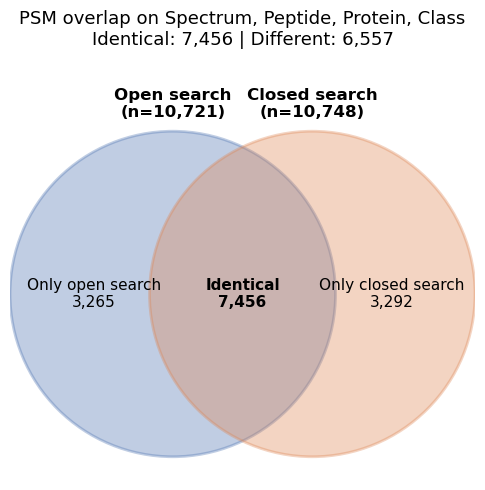

In [35]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

open_cmp = open_search_psm[colst_to_compare]
search_cmp = search_psm[colst_to_compare]

identical_count = len(pd.merge(open_cmp, search_cmp, how="inner"))
only_open = (
    pd.merge(open_cmp, search_cmp, how="left", indicator=True)
    .query("_merge == 'left_only'")
    .shape[0]
)
only_search = (
    pd.merge(search_cmp, open_cmp, how="left", indicator=True)
    .query("_merge == 'left_only'")
    .shape[0]
)
different_count = only_open + only_search

fig, ax = plt.subplots(figsize=(8, 5))

circle_open = Circle((0.35, 0.5), 0.35, facecolor="#4C72B0", alpha=0.35, edgecolor="#4C72B0", lw=2)
circle_search = Circle((0.65, 0.5), 0.35, facecolor="#DD8452", alpha=0.35, edgecolor="#DD8452", lw=2)
ax.add_patch(circle_open)
ax.add_patch(circle_search)

ax.text(0.18, 0.5, f"Only open search\n{only_open:,}", ha="center", va="center", fontsize=11)
ax.text(0.5, 0.5, f"Identical\n{identical_count:,}", ha="center", va="center", fontsize=11, fontweight="bold")
ax.text(0.82, 0.5, f"Only closed search\n{only_search:,}", ha="center", va="center", fontsize=11)
ax.text(0.35, 0.88, f"Open search\n(n={len(open_cmp):,})", ha="center", fontsize=12, fontweight="bold")
ax.text(0.65, 0.88, f"Closed search\n(n={len(search_cmp):,})", ha="center", fontsize=12, fontweight="bold")

ax.set_xlim(0, 1)
ax.set_ylim(0.1, 1)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(
    f"PSM overlap on {', '.join(colst_to_compare)}\n"
    f"Identical: {identical_count:,} | Different: {different_count:,}",
    fontsize=13,
    pad=12,
)

plt.tight_layout()
plt.show()

In [30]:
identical_df['Category'].value_counts()

Category
NOT_SPLICED    7081
SPLICED         375
Name: count, dtype: int64

In [42]:
open_only = open_search_psm[~open_search_psm['Spectrum'].isin(identical_df['Spectrum'])]
open_only.head()

,Spectrum,Peptide,Protein,Class,Category
2196,GR_LCL_2D_ETHCD_fr3_immunopeptidome.01747.01747.2,AAACQNGSIQI,sp|Q9NW82|WDR70_HUMAN,Swiss-Prot,NOT_SPLICED
14871,GR_LCL_2D_ETHCD_fr8_immunopeptidome.03335.03335.3,AAAGKLKSFAR,sp|LIEPE-SPLICED-3127;|O75448|MED24;453_455_45...,Spliced_only,SPLICED
3051,GR_LCL_2D_ETHCD_fr3_immunopeptidome.03600.03600.2,AAALLAGGTGL,sp|P55291|CAD15_HUMAN,Swiss-Prot,NOT_SPLICED
7521,GR_LCL_2D_ETHCD_fr5_immunopeptidome.01988.01988.2,AAASLPVSVAG,sp|Q96SC8|DMTA2_HUMAN,Swiss-Prot,NOT_SPLICED
1008,GR_LCL_2D_ETHCD_fr2_immunopeptidome.03096.03096.2,AAEFSNVMIIY,sp|Q9UDY8|MALT1_HUMAN,Swiss-Prot,NOT_SPLICED


In [43]:
open_only['Category'].value_counts()

Category
NOT_SPLICED    3109
SPLICED         156
Name: count, dtype: int64

In [44]:
only_closed = search_psm[~search_psm['Spectrum'].isin(identical_df['Spectrum'])]
only_closed['Category'].value_counts()

Category
NOT_SPLICED    3110
SPLICED         182
Name: count, dtype: int64

In [45]:
spliced_closed = only_closed[only_closed['Category'] == 'SPLICED']
spliced_open = open_only[open_only['Category'] == 'SPLICED']
spliced_identical = identical_df[identical_df['Category'] == 'SPLICED']

print(spliced_closed.shape)
print(spliced_open.shape)
print(spliced_identical.shape)


(182, 5)
(156, 5)
(375, 5)


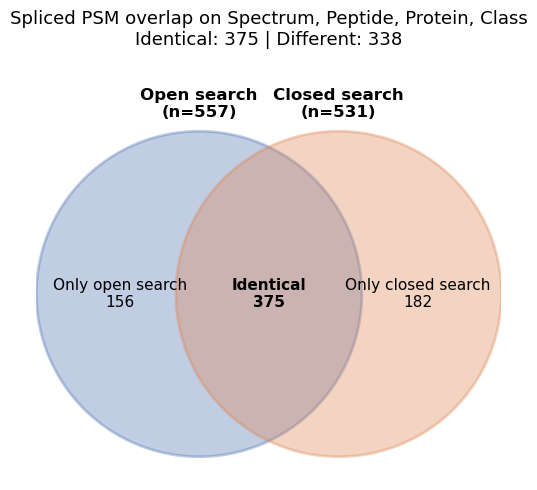

In [52]:
identical_count = len(spliced_identical)
only_open = (
    spliced_open.shape[0]
)
only_closed = (
    spliced_closed.shape[0]
)
different_count = only_open + only_search
closed = only_open+identical_count
open = only_closed+identical_count

fig, ax = plt.subplots(figsize=(8, 5))

circle_open = Circle((0.35, 0.5), 0.35, facecolor="#4C72B0", alpha=0.35, edgecolor="#4C72B0", lw=2)
circle_search = Circle((0.65, 0.5), 0.35, facecolor="#DD8452", alpha=0.35, edgecolor="#DD8452", lw=2)
ax.add_patch(circle_open)
ax.add_patch(circle_search)

ax.text(0.18, 0.5, f"Only open search\n{only_open:,}", ha="center", va="center", fontsize=11)
ax.text(0.5, 0.5, f"Identical\n{identical_count:,}", ha="center", va="center", fontsize=11, fontweight="bold")
ax.text(0.82, 0.5, f"Only closed search\n{only_search:,}", ha="center", va="center", fontsize=11)
ax.text(0.35, 0.88, f"Open search\n(n={open:,})", ha="center", fontsize=12, fontweight="bold")
ax.text(0.65, 0.88, f"Closed search\n(n={closed:,})", ha="center", fontsize=12, fontweight="bold")

ax.set_xlim(0, 1)
ax.set_ylim(0.1, 1)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(
    f"Spliced PSM overlap on {', '.join(colst_to_compare)}\n"
    f"Identical: {identical_count:,} | Different: {different_count:,}",
    fontsize=13,
    pad=12,
)

plt.tight_layout()
plt.show()